# Fitness Prediction on ProteinGym — D2D vs. zero-shot baselines

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q evcouplings requests pandas numpy scipy scikit-learn seaborn matplotlib tqdm
# EVcouplings from the develop branch (as in the original notebook):
!pip install -q https://github.com/debbiemarkslab/EVcouplings/archive/develop.zip

from __future__ import annotations

import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from requests.adapters import HTTPAdapter
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
from urllib3.util.retry import Retry

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.3/263.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.7/113.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 45.4 MB/s eta 0:00:00
     \ 18.6 MB 15.3 MB/s 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Configuration

**Important for the ESM3 / ProSST request:** those columns only exist in the merged
per-assay score files from **ProteinGym v1.3** (v1.2 and earlier do not have them).
If your `zero_shot_substitutions_scores/` folder predates that, re-download:

```bash
VERSION="v1.3"
curl -o zero_shot_substitutions_scores.zip \
  https://marks.hms.harvard.edu/proteingym/ProteinGym_${VERSION}/zero_shot_substitutions_scores.zip
unzip zero_shot_substitutions_scores.zip
```

The column names below are the keys of `model_list_zero_shot_substitutions_DMS`
in ProteinGym's `config.json`, which is what the merge script writes as headers.

In [ ]:
BASE = Path("/content/drive/MyDrive/Colab Notebooks/5thYear/D2D_revamp/ProteinGym")

PATHS = {
    "d2d_features": BASE / "D2D_features",
    "zero_shot": BASE / "zero_shot_substitutions_scores",
    "msas": BASE / "msas",
    "mapping": BASE / "mapping_proteingym.csv",
    "dms_level": BASE / "DMS_substitutions_Spearman_DMS_level.csv",
    "aggregated": BASE / "aggregated_scores_multiple_mutants_clean.csv",
    "cache": BASE / "_cache",
    "figures": BASE.parent.parent / "figures",
}
PATHS["cache"].mkdir(parents=True, exist_ok=True)
PATHS["figures"].mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Model registry. `col` = column in the merged per-assay CSV.
# `sign` flips models whose raw score is anti-correlated with fitness.
#
#   ProteinGym's config.json gives RSALOR directionality = -1. Whether the merged
#   file has *already* applied it varies by release, so RSALOR is checked at
#   runtime in Section 2b instead of being hard-coded -- see AUTO_ORIENT below.
# ---------------------------------------------------------------------------
MODELS = {
    # ---- MSA ---------------------------------------------------------------
    "EVmutation":       dict(col="EVmutation",                 sign=+1, modality="MSA"),
    "DeepSequence":     dict(col="DeepSequence_single",        sign=+1, modality="MSA"),
    "EVE":              dict(col="EVE_single",                 sign=+1, modality="MSA"),
    "GEMME":            dict(col="GEMME",                      sign=+1, modality="MSA"),
    "MSA_Transformer":  dict(col="MSA_Transformer_single",     sign=+1, modality="MSA"),
    "TranceptEVE":      dict(col="TranceptEVE_L",              sign=+1, modality="MSA"),
    # ---- single sequence ---------------------------------------------------
    "Unirep":           dict(col="Unirep",                     sign=+1, modality="pLM"),
    "ESM1v":            dict(col="ESM1v_single",               sign=+1, modality="pLM"),
    "VESPAl":           dict(col="VESPAl",                     sign=+1, modality="pLM"),
    "ProtGPT2":         dict(col="ProtGPT2",                   sign=+1, modality="pLM"),
    #"Tranception":      dict(col="Tranception_L_no_retrieval", sign=+1, modality="pLM"),
    # ---- structure ---------------------------------------------------------
    "ProteinMPNN":      dict(col="ProteinMPNN",                sign=+1, modality="Structure"),
    "RSALOR":           dict(col="RSALOR",                     sign=+1, modality="MSA & Structure"),
    # ---- added in this version --------------------------------------------
    "ESM3":             dict(col="ESM3",                       sign=+1,
                             modality="pLM, Structure & Function"),
    "ProSST":           dict(col="ProSST-2048",                sign=+1,
                             modality="pLM & Structure"),
}

# `modality` follows ProteinGym's own labelling -- the "Input modalities" column of
# the benchmarks table, which is generated from the `model_type` field of each entry
# in config.json. The website itself is client-rendered, so those two files are the
# checkable source. Notes on the ones that are easy to get wrong:
#   RSALOR      -- MSA & Structure. It combines log-odds ratios from the alignment
#                  with relative solvent accessibility; calling it structure-only
#                  drops half of what it uses.
#   ProSST      -- Single sequence & Structure (quantised structure vocabulary).
#   ESM3        -- Single sequence, Structure & Function annotations.
#   Unirep      -- listed Single sequence; the MSA-evotuned variant is a separate
#                  entry (Unirep_evotune), not the column scored here.
#   Tranception -- Single sequence for the _no_retrieval column used here; the
#                  retrieval variants are MSA.
#   EVE         -- shown as "Alignment-based model" on the site, "MSA" in config.

# D2D is not a ProteinGym baseline, so its modality is declared here:
# GMM features over MSA-derived representations combined with pLM log-probabilities.
D2D_MODALITY = "MSA & pLM"

# ProSST ships six structure-vocabulary sizes; 2048 is the one the authors report
# as best and the one the leaderboard headline number refers to. Swap freely:
#   "ProSST-20" / "-128" / "-512" / "-1024" / "-2048" / "-4096"
# ESM3 is the open-weights checkpoint ("ESM3_open_score" upstream).

# D2D: spearman(GMM_features, label) is negative by construction, so flip it once,
# here, rather than with a `[-x for x in ...]` list comprehension three cells later.
D2D_SIGN = -1
CONFIDENCE_THRESHOLD = 30.0     # mean log_prob; was the hard-coded 30 in cell 12
MIN_N_FOR_SPEARMAN = 10         # below this a per-assay rho is noise
AUTO_ORIENT = ["RSALOR"]        # models whose sign is inferred from the data

## 2. Helpers

In [ ]:
def nanmean(x):
    """Replacement for the notebook's `Average`. Returns a float, not a 0-d array,
    so `.tolist()` calls are unnecessary."""
    a = np.asarray(list(x), dtype=float)
    return float(np.nanmean(a)) if a.size else np.nan


def safe_spearman(x, y, min_n=MIN_N_FOR_SPEARMAN):
    """Spearman rho that returns NaN instead of raising / silently returning nan
    on short, constant or NaN-containing inputs."""
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    ok = x.notna() & y.notna()
    if ok.sum() < min_n:
        return np.nan
    x, y = x[ok], y[ok]
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan
    return float(stats.spearmanr(x, y).statistic)


def parse_features(cell):
    """'[0.1, 0.2, ...]' -> mean. Tolerates malformed rows instead of crashing
    the whole loop (the original `float(i)` would raise on any stray token)."""
    try:
        return float(np.mean([float(v) for v in str(cell).strip("[]").split(",")]))
    except (ValueError, TypeError):
        return np.nan


def mutation_positions(mutant):
    """'A12P:D34N' -> [12, 34]. 1-indexed, as in ProteinGym."""
    out = []
    for m in str(mutant).split(":"):
        m = m.strip()
        if len(m) > 2 and m[1:-1].isdigit():
            out.append(int(m[1:-1]))
    return out


def n_mutations(mutant):
    return str(mutant).count(":") + 1

### 2a. MSA statistics

In [ ]:
from collections import OrderedDict  # noqa: E402

try:
    from evcouplings.align import Alignment, read_fasta  # noqa: F401
    HAVE_EVCOUPLINGS = True
except ImportError:
    HAVE_EVCOUPLINGS = False
    print("evcouplings not installed -- MSA-derived columns will be NaN.")


def read_msa(path):
    """Read an alignment, choosing the parser by extension. a3m insert columns are
    deleted so that column j maps to query position j+1."""
    path = Path(path)
    with open(path) as fh:
        if path.suffix.lower() in (".a3m", ".a2m"):
            return Alignment.from_file(fh, format="a3m", a3m_inserts="delete")
        if path.suffix.lower() in (".sto", ".stockholm"):
            return Alignment.from_file(fh, format="stockholm")
        return Alignment.from_file(fh, format="fasta")


def msa_protocol(a3m_path, min_coverage=0.5):
    """Hopf-style *sequence* filtering: drop rows covering less than `min_coverage`
    of the query. Columns are left untouched on purpose (see the note above).
    Returns an Alignment at full query width, or None."""
    a3m_path = Path(a3m_path)
    if not (HAVE_EVCOUPLINGS and a3m_path.exists()):
        return None
    try:
        aln = read_msa(a3m_path)
    except Exception as exc:
        print(f"  ! could not read {a3m_path.name}: {exc}")
        return None

    coverage = 1.0 - aln.count("-", axis="seq")
    keep = np.where(coverage >= min_coverage)[0]
    if keep.size == 0:
        return None
    if keep.size < aln.N:
        aln = aln.select(sequences=keep)   # rows only -> column indices preserved
    return aln


def describe_frequencies(alignment, first_index, target_seq_index=None):
    """Unchanged from the original notebook apart from formatting."""
    fi = alignment.frequencies
    conservation = alignment.conservation()
    fi_cols = {c: fi[:, i] for c, i in alignment.alphabet_map.items()}
    target_seq = (alignment[target_seq_index] if target_seq_index is not None
                  else np.full((alignment.L,), np.nan))
    info = pd.DataFrame({
        "i": range(first_index, first_index + alignment.L),
        "A_i": target_seq,
        "conservation": conservation,
        **fi_cols,
    })
    return info.loc[:, ["i", "A_i", "conservation"] + list(alignment.alphabet)]

### 2b. AlphaSync RSA lookup

In [ ]:
ALPHASYNC_URL = "https://alphasync.stjude.org/api/v1/protein/"

_session = requests.Session()
_session.mount("https://", HTTPAdapter(max_retries=Retry(
    total=3, backoff_factor=0.5, status_forcelist=[429, 500, 502, 503, 504])))


def fetch_rsa_table(uniprot):
    """{site -> relasa} for one UniProt accession. Cached under PATHS['cache']."""
    cache_file = PATHS["cache"] / f"alphasync_{uniprot}.json"
    if cache_file.exists():
        try:
            data = json.loads(cache_file.read_text())
        except json.JSONDecodeError:
            cache_file.unlink()
            data = None
        if data is not None:
            return pd.json_normalize(data) if data else None
    try:
        r = _session.get(ALPHASYNC_URL + uniprot,
                         headers={"Accept": "application/json"}, timeout=30)
    except requests.RequestException as exc:
        print(f"  ! AlphaSync {uniprot}: {exc}")
        return None
    if r.status_code != 200:
        cache_file.write_text("[]")          # negative cache: don't re-ask
        return None
    data = r.json()
    cache_file.write_text(json.dumps(data))
    return pd.json_normalize(data)


def mean_rsa(rsa_df, mutants):
    if rsa_df is None or "site" not in rsa_df.columns:
        return np.nan
    lookup = dict(zip(rsa_df["site"], rsa_df["relasa"]))
    vals = [lookup.get(p, np.nan) for m in mutants for p in mutation_positions(m)]
    return nanmean(vals)

## 3. Build the assay-level table — one pass

Everything the figures need is computed here and stored as one row per DMS assay.
Each row is a dict, so a missing MSA or a failed API call leaves a NaN in one
column rather than shifting every list out of alignment.

In [ ]:
mapping = pd.read_csv(PATHS["mapping"])
dms_level = pd.read_csv(PATHS["dms_level"])
feature_files = sorted(p for p in PATHS["d2d_features"].iterdir() if p.suffix == ".csv")
print(f"D2D feature files: {len(feature_files)}")

STUDY_RENAMES = {"Q6WV13_9MAXI_Somermeyer_2022": "Q6WV12_9MAXI_Somermeyer_2022"}
DEPTH_BINS = {"single": 1, "double": 2, "triple": 3, "quadruple": 4, "fiveplus": 5}


def study_name_from_path(path):
    name = path.stem.split("D2D_features_")[-1]
    return STUDY_RENAMES.get(name, name)


records, missing_cols = [], {}

for path in tqdm(feature_files, desc="assays"):
    study = study_name_from_path(path)
    row = {"DMS_ID": study}

    # ---- D2D ------------------------------------------------------------
    d2d = pd.read_csv(path)
    d2d["GMM_features"] = d2d["features"].map(parse_features)
    d2d["mutant"] = d2d["mutation"].astype(str).str.split("_").str[-1]
    d2d["n_mut"] = d2d["mutant"].map(n_mutations)

    row["n_variants"] = len(d2d)
    row["D2D"] = D2D_SIGN * safe_spearman(d2d["GMM_features"], d2d["label"])
    row["mean_log_prob"] = nanmean(d2d["log_prob"])
    row["mean_log_prob_norm"] = nanmean(
        MinMaxScaler().fit_transform(d2d[["log_prob"]].to_numpy(float)).ravel()
    )

    # D2D by mutational depth (was a separate 130-line loop in cell 24)
    for label, k in DEPTH_BINS.items():
        sub = d2d[d2d["n_mut"] >= k] if label == "fiveplus" else d2d[d2d["n_mut"] == k]
        row[f"D2D_{label}"] = D2D_SIGN * safe_spearman(sub["GMM_features"], sub["label"])
        row[f"n_{label}"] = len(sub)
        row[f"logprob_{label}"] = nanmean(sub["log_prob"]) if len(sub) else np.nan

    # ---- reference metadata --------------------------------------------
    entry = "_".join(study.split("_")[:2])
    row["entry"] = entry
    hit = mapping.loc[mapping["From"] == entry, "Entry"]
    uniprot = hit.iloc[0] if len(hit) else None
    row["uniprot"] = uniprot

    meta = dms_level[dms_level["DMS ID"] == study]
    row["selection_type"] = meta["Selection Type"].iloc[0] if len(meta) else np.nan

    # ---- structure: relative solvent accessibility ----------------------
    row["mean_RSA"] = mean_rsa(fetch_rsa_table(uniprot), d2d["mutant"]) if uniprot else np.nan

    # ---- MSA: gaps + conservation at mutated positions ------------------
    aln = msa_protocol(PATHS["msas"] / f"{entry}.a3m")
    if aln is not None:
        gap_perc = aln.count(axis="pos", char="-")
        cons = describe_frequencies(aln, 0)["conservation"].to_numpy()
        gaps, conservation, out_of_range = [], [], 0
        for m in d2d["mutant"]:
            for p in mutation_positions(m):
                idx = p - 1          # column j <-> query position j+1
                if 0 <= idx < len(gap_perc):
                    gaps.append(gap_perc[idx])
                    conservation.append(cons[idx])
                else:
                    out_of_range += 1
        row["msa_L"] = aln.L
        row["n_pos_out_of_range"] = out_of_range
        row["msa_depth"] = aln.N
        row["mean_gaps"] = nanmean(gaps)
        row["mean_conservation"] = nanmean(conservation)
    else:
        row["msa_depth"] = row["mean_gaps"] = row["mean_conservation"] = np.nan
        row["msa_L"] = row["n_pos_out_of_range"] = np.nan

    # ---- zero-shot baselines -------------------------------------------
    score_file = PATHS["zero_shot"] / f"{study}.csv"
    if score_file.exists():
        rest = pd.read_csv(score_file)
        for name, spec in MODELS.items():
            if spec["col"] in rest.columns:
                row[name] = spec["sign"] * safe_spearman(rest[spec["col"]], rest["DMS_score"])
            else:
                row[name] = np.nan
                missing_cols[name] = missing_cols.get(name, 0) + 1
    else:
        for name in MODELS:
            row[name] = np.nan

    records.append(row)

dms = pd.DataFrame(records)
print(f"\nassay table: {dms.shape[0]} rows x {dms.shape[1]} cols")

if missing_cols:
    print("\nModels missing from the merged score files (per assay count):")
    for name, n in sorted(missing_cols.items(), key=lambda kv: -kv[1]):
        print(f"  {name:<18} {MODELS[name]['col']:<26} missing in {n}/{len(feature_files)}")
    print("\n-> If ESM3 / ProSST-2048 are listed above, your "
          "zero_shot_substitutions_scores/ predates ProteinGym v1.3. See Section 1.")

# Mutated positions falling outside the alignment mean the a3m is not indexed
# against the DMS target sequence (wrong isoform, or an offset domain construct).
bad = dms[dms.get("n_pos_out_of_range", pd.Series(dtype=float)).fillna(0) > 0]
if len(bad):
    print(f"\n{len(bad)} assay(s) have mutated positions outside their alignment "
          "-- check that the a3m query matches the DMS target_seq:")
    print(bad[["DMS_ID", "msa_L", "n_pos_out_of_range"]].to_string(index=False))

D2D feature files: 126


assays:   0%|          | 0/126 [00:00<?, ?it/s]


assay table: 126 rows x 44 cols


In [ ]:
# Sign check for models whose merged-file orientation is release-dependent.
for name in AUTO_ORIENT:
    if name in dms and dms[name].notna().any():
        med = dms[name].median()
        if med < 0:
            print(f"{name}: median rho = {med:+.3f} -> flipping sign "
                  "(merged file stores the raw, anti-correlated score)")
            dms[name] = -dms[name]
        else:
            print(f"{name}: median rho = {med:+.3f} -> already oriented, left as is")

# Confidence as a column, not a separately-filtered list.
dms["d2d_confident"] = dms["mean_log_prob"] >= CONFIDENCE_THRESHOLD
print(f"\nconfident assays (mean log_prob >= {CONFIDENCE_THRESHOLD}): "
      f"{int(dms['d2d_confident'].sum())}/{len(dms)}")

dms.to_csv(BASE / "assay_level_summary.csv", index=False)

RSALOR: median rho = +0.456 -> already oriented, left as is

confident assays (mean log_prob >= 30.0): 114/126


In [ ]:
PREDICTORS = ["D2D"] + list(MODELS)

summary = (dms[PREDICTORS].agg(["mean", "median", "std", "count"]).T
           .sort_values("mean", ascending=False).round(3))
summary

,mean,median,std,count
VenusREM,0.481,0.493,0.151,126.0
ProSST,0.465,0.480,0.157,126.0
TranceptEVE,0.456,0.459,0.151,126.0
GEMME,0.446,0.446,0.143,126.0
RSALOR,0.434,0.456,0.162,126.0
EVE,0.431,0.443,0.148,126.0
D2D,0.424,0.434,0.160,126.0
MSA_Transformer,0.417,0.425,0.149,126.0
EVmutation,0.408,0.416,0.141,126.0
ESM3,0.405,0.414,0.160,126.0


## 4. Figures

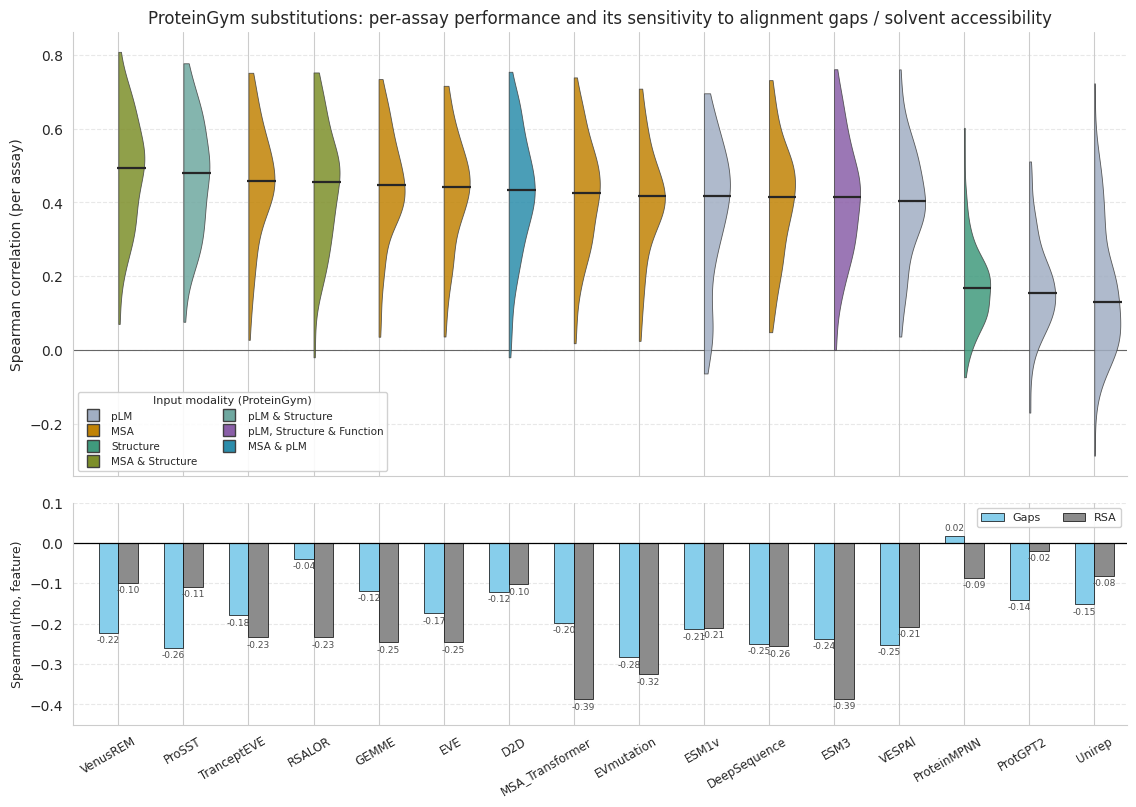

,modality,median_rho,mean_rho,n_assays,Gaps,RSA
VenusREM,MSA & Structure,0.493,0.481,126,-0.222,-0.099
ProSST,pLM & Structure,0.480,0.465,126,-0.259,-0.108
TranceptEVE,MSA,0.459,0.456,126,-0.180,-0.233
RSALOR,MSA & Structure,0.456,0.434,126,-0.040,-0.234
GEMME,MSA,0.446,0.446,126,-0.118,-0.246
EVE,MSA,0.443,0.431,126,-0.174,-0.246
D2D,MSA & pLM,0.434,0.424,126,-0.121,-0.103
MSA_Transformer,MSA,0.425,0.417,126,-0.197,-0.387
EVmutation,MSA,0.416,0.408,126,-0.284,-0.325
ESM1v,pLM,0.416,0.379,126,-0.213,-0.210


In [ ]:
from matplotlib.lines import Line2D  # noqa: E402

# One colour per ProteinGym modality. Shared components get related hues:
# gold = alignment involved, green = structure involved, grey-blue = sequence only.
MODALITY_COLORS = {
    "pLM":                        "#a1aec3",
    "MSA":                         "#C18305",
    "Structure":                  "#409a7d",
    "MSA & Structure":            "#7d8f2a",
    "pLM & Structure":            "#6fa8a0",
    "pLM, Structure & Function":  "#8a5fa8",
    "MSA & pLM":                  "#2b8dab",
}
SENS = {"Gaps": ("mean_gaps", "skyblue"), "RSA": ("mean_RSA", "0.55")}


'''
def half_violin(ax, x, values, width=0.40, color="0.5", side="right"):
    """One-sided KDE violin at position `x`. Silently skipped for degenerate input."""
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if v.size < 3 or np.isclose(v.std(), 0):
        return
    try:
        kde = stats.gaussian_kde(v)
    except np.linalg.LinAlgError:
        return
    grid = np.linspace(v.min(), v.max(), 256)      # cut=0: no tails past the data
    dens = kde(grid)
    dens = dens / dens.max() * width
    sign = 1 if side == "right" else -1
    ax.fill_betweenx(grid, x, x + sign * dens, facecolor=color,
                     edgecolor="0.25", linewidth=0.6, alpha=0.85, zorder=2)
'''

# order: predictors present in the data, ranked by median rho
candidates = ["D2D"] + list(MODELS)
order = [p for p in candidates if dms[p].notna().sum() >= 3]
order = sorted(order, key=lambda p: dms[p].median(), reverse=True)
modality = {p: (D2D_MODALITY if p == "D2D" else MODELS[p]["modality"]) for p in order}

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(max(12, 0.85 * len(order)), 9), sharex=True,
    gridspec_kw={"height_ratios": [3, 1.5], "hspace": 0.08})

rng = np.random.RandomState(0)
for i, p in enumerate(order):
    vals = dms[p].dropna().to_numpy()
    colour = MODALITY_COLORS[modality[p]]
    half_violin(ax, i, vals, color=colour, side="right")

    # raw assays on the left half
    #ax.scatter(i - 0.10 - rng.uniform(0, 0.22, vals.size), vals,
    #           s=7, color=colour, edgecolor="white", linewidth=0.25,
    #           alpha=0.65, zorder=3)
    ax.hlines(np.median(vals), i - 0.02, i + 0.42, color="0.15", lw=1.6, zorder=4)

ax.axhline(0, color="0.4", lw=0.8, zorder=1)
ax.set_ylabel("Spearman correlation (per assay)")
ax.set_title("ProteinGym substitutions: per-assay performance and its sensitivity "
             "to alignment gaps / solvent accessibility")
ax.ylim(-0.25, 0.6)
ax.grid(axis="y", ls="--", alpha=0.45)
ax.set_axisbelow(True)

used = [m for m in MODALITY_COLORS if m in set(modality.values())]
ax.legend(handles=[Line2D([], [], marker="s", ls="", markersize=8,
                          markerfacecolor=MODALITY_COLORS[m],
                          markeredgecolor="0.25", label=m) for m in used],
          title="Input modality (ProteinGym)", loc="lower left", fontsize=7.5,
          title_fontsize=8, framealpha=0.9, ncol=2)

# ---- lower panel: sensitivity as grouped bars, same x order ---------------
x = np.arange(len(order))
width = 0.3
sens_tbl = {}
for k, (label, (col, colour)) in enumerate(SENS.items()):
    rhos = [safe_spearman(dms[p], dms[col]) for p in order]
    sens_tbl[label] = rhos
    bars = ax2.bar(x + (k - (len(SENS) - 1) / 2) * width, rhos, width,
                   label=label, color=colour, edgecolor="black", linewidth=0.5,
                   zorder=2)
    ax2.bar_label(bars, fmt="%.2f", padding=2, fontsize=6.5, color="0.3")

ax2.axhline(0, color="black", lw=0.9)
ax2.set_ylabel("Spearman(rho, feature)", fontsize=9)
ax2.set_ylim(-0.45, 1)
ax2.grid(axis="y", ls="--", alpha=0.45)
ax2.set_axisbelow(True)
ax2.legend(loc="upper right", fontsize=8, ncol=len(SENS), framealpha=0.9)
#ax2.text(0.004, 0.05, "negative = worse on gappy / exposed assays",
#         transform=ax2.transAxes, fontsize=7.5, color="0.35")

ax2.set_xticks(x)
ax2.set_xticklabels([f"{p}" for p in order],
                    rotation=30, ha="right", fontsize=8.5)


import matplotlib.transforms as mtransforms

dx = 2 / 10                      # 2 mm, expressed in inches
offset = mtransforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
for lbl in ax2.xaxis.get_majorticklabels():
    lbl.set_transform(lbl.get_transform() + offset)


ax2.set_xlim(-0.7, len(order) -0.5 )
sns.despine(fig=fig)
plt.savefig('/content/drive/MyDrive/D2D_paper/review_CSBJ/proteingym_all.jpg', dpi=600, bbox_inches="tight")
plt.show()

pd.DataFrame({"modality": [modality[p] for p in order],
              "median_rho": [dms[p].median() for p in order],
              "mean_rho": [dms[p].mean() for p in order],
              "n_assays": [int(dms[p].notna().sum()) for p in order],
              **sens_tbl}, index=order).round(3)

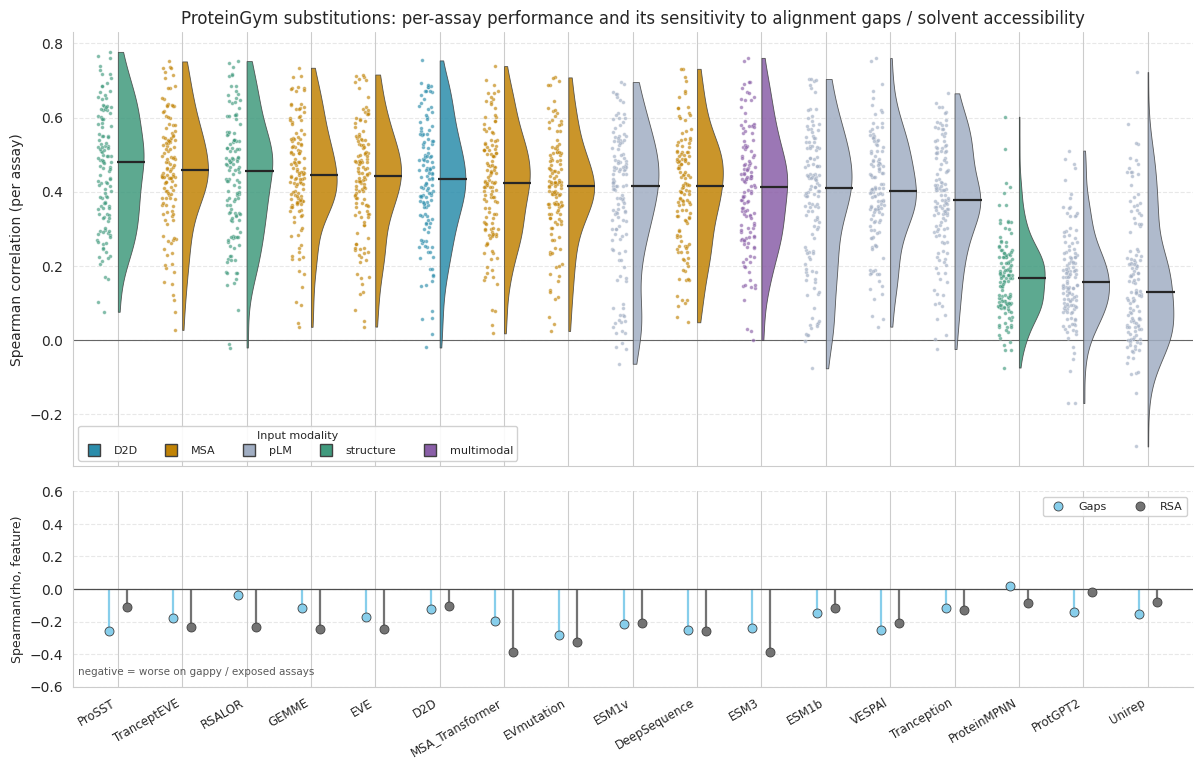

,median_rho,mean_rho,n_assays,Gaps,RSA
ProSST,0.480,0.465,126,-0.259,-0.108
TranceptEVE,0.459,0.456,126,-0.180,-0.233
RSALOR,0.456,0.434,126,-0.040,-0.234
GEMME,0.446,0.446,126,-0.118,-0.246
EVE,0.443,0.431,126,-0.174,-0.246
D2D,0.434,0.424,126,-0.121,-0.103
MSA_Transformer,0.425,0.417,126,-0.197,-0.387
EVmutation,0.416,0.408,126,-0.284,-0.325
ESM1v,0.416,0.379,126,-0.213,-0.210
DeepSequence,0.416,0.404,126,-0.250,-0.256


In [ ]:
from matplotlib.lines import Line2D

PALETTE = {"D2D": "#2b8dab", "MSA": "#C18305", "pLM": "#a1aec3",
           "structure": "#409a7d", "multimodal": "#8a5fa8"}
SENS = {"Gaps": ("mean_gaps", "skyblue"), "RSA": ("mean_RSA", "0.45")}


def half_violin(ax, x, values, width=0.40, color="0.5", side="right"):
    """One-sided KDE violin at position `x`. Silently skipped for degenerate input."""
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if v.size < 3 or np.isclose(v.std(), 0):
        return
    try:
        kde = stats.gaussian_kde(v)
    except np.linalg.LinAlgError:
        return
    grid = np.linspace(v.min(), v.max(), 256)      # cut=0: no tails past the data
    dens = kde(grid)
    dens = dens / dens.max() * width
    sign = 1 if side == "right" else -1
    ax.fill_betweenx(grid, x, x + sign * dens, facecolor=color,
                     edgecolor="0.25", linewidth=0.6, alpha=0.85, zorder=2)


# order: predictors present in the data, ranked by median rho
candidates = ["D2D"] + list(MODELS)
order = [p for p in candidates if dms[p].notna().sum() >= 3]
order = sorted(order, key=lambda p: dms[p].median(), reverse=True)
family = {p: ("D2D" if p == "D2D" else MODELS[p]["family"]) for p in order}

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(max(12, 0.85 * len(order)), 8.5), sharex=True,
    gridspec_kw={"height_ratios": [3, 1.35], "hspace": 0.08})

rng = np.random.RandomState(0)
for i, p in enumerate(order):
    vals = dms[p].dropna().to_numpy()
    colour = PALETTE[family[p]]
    half_violin(ax, i, vals, color=colour, side="right")
    # raw assays on the left half
    ax.scatter(i - 0.10 - rng.uniform(0, 0.22, vals.size), vals,
               s=7, color=colour, edgecolor="white", linewidth=0.25,
               alpha=0.65, zorder=3)
    ax.hlines(np.median(vals), i - 0.02, i + 0.42, color="0.15", lw=1.6, zorder=4)

ax.axhline(0, color="0.4", lw=0.8, ls="-", zorder=1)
ax.set_ylabel("Spearman correlation (per assay)")
ax.set_title("ProteinGym substitutions: per-assay performance and its sensitivity "
             "to alignment gaps / solvent accessibility")
ax.grid(axis="y", ls="--", alpha=0.45)
ax.set_axisbelow(True)
ax.legend(handles=[Line2D([], [], marker="s", ls="", markersize=8,
                          markerfacecolor=c, markeredgecolor="0.25", label=f)
                   for f, c in PALETTE.items()],
          title="Input modality", loc="lower left", fontsize=8, title_fontsize=8,
          framealpha=0.9, ncol=len(PALETTE))

# ---- lower panel: sensitivity, same x order -------------------------------
offsets = np.linspace(-0.14, 0.14, len(SENS))
sens_tbl = {}
for (label, (col, colour)), dx in zip(SENS.items(), offsets):
    rhos = [safe_spearman(dms[p], dms[col]) for p in order]
    sens_tbl[label] = rhos
    xs = np.arange(len(order)) + dx
    ax2.vlines(xs, 0, rhos, color=colour, lw=1.6, zorder=2)
    ax2.scatter(xs, rhos, s=42, color=colour, edgecolor="0.25",
                linewidth=0.6, zorder=3, label=label)

ax2.axhline(0, color="0.3", lw=0.9)
ax2.set_ylabel("Spearman(rho, feature)", fontsize=9)
ax2.set_ylim(-0.6, 0.6)
ax2.grid(axis="y", ls="--", alpha=0.45)
ax2.set_axisbelow(True)
ax2.legend(loc="upper right", fontsize=8, ncol=len(SENS), framealpha=0.9)
ax2.text(0.005, 0.06, "negative = worse on gappy / exposed assays",
         transform=ax2.transAxes, fontsize=7.5, color="0.35")

ax2.set_xticks(np.arange(len(order)))
#ax2.set_xticklabels([f"{p}\n(n={int(dms[p].notna().sum())})" for p in order],
#                    rotation=30, ha="right", fontsize=8.5)
ax2.set_xticklabels([f"{p}" for p in order],
                    rotation=30, ha="right", fontsize=8.5)
ax2.set_xlim(-0.7, len(order) - 0.3)
sns.despine(fig=fig)
plt.savefig(PATHS["figures"] / "ProteinGym_all.png", dpi=300, bbox_inches="tight")
plt.show()

pd.DataFrame({"median_rho": [dms[p].median() for p in order],
              "mean_rho": [dms[p].mean() for p in order],
              "n_assays": [int(dms[p].notna().sum()) for p in order],
              **sens_tbl}, index=order).round(3)